# Autoencoder — Anomaly Detection

Trains a convolutional autoencoder on **normal segments only**. At inference,
segments with high reconstruction error are flagged as anomalous.

Run this notebook twice — once with `REPRESENTATION = 'mel'`, once with `'fft'` —
to compare which representation gives better anomaly separation.
Plots are saved to `plots/autoencoder_{representation}_*.png`.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score
from pathlib import Path

REPRESENTATION = 'fft'   # 'mel' or 'fft'
BOTTLENECK     = 64
BATCH_SIZE     = 64
EPOCHS         = 50
VAL_SPLIT      = 0.1
SEED           = 42

DATA_DIR  = Path('../processing') / REPRESENTATION
MODEL_DIR = Path('models')
PLOTS_DIR = Path('plots')
MODEL_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

## Load data

In [11]:
train = np.load(DATA_DIR / 'train.npz')
test  = np.load(DATA_DIR / 'test.npz')

X_train_all = train['X']          # (24801, 32, 32)
y_train_bin = train['y_binary']   # 0=normal, 1=broken

X_test      = test['X']           # (6047, 32, 32)
y_test_bin  = test['y_binary']

# Add channel dim: (N, 32, 32) → (N, 32, 32, 1)
X_train_all = X_train_all[..., np.newaxis]
X_test      = X_test[..., np.newaxis]

# Autoencoder trains on normal only
X_normal = X_train_all[y_train_bin == 0]
print(f'Normal train segments: {len(X_normal)}')
print(f'Test segments: {len(X_test)}  (normal: {(y_test_bin==0).sum()}, broken: {(y_test_bin==1).sum()})')

Normal train segments: 6773
Test segments: 6047  (normal: 1728, broken: 4319)


## Build model

In [12]:
def build_autoencoder(bottleneck=BOTTLENECK):
    inputs = keras.Input(shape=(32, 32, 1))

    # Encoder — three conv+pool stages: 32→16→8→4
    x = layers.Conv2D(8, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)           # (16, 16, 8)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)           # (8, 8, 16)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)           # (4, 4, 32)  = 512 values
    x = layers.Flatten()(x)
    encoded = layers.Dense(bottleneck, activation='relu')(x)  # 512→64

    # Decoder — mirror
    x = layers.Dense(4 * 4 * 32, activation='relu')(encoded)
    x = layers.Reshape((4, 4, 32))(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)           # (8, 8, 32)
    x = layers.Conv2DTranspose(16, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)           # (16, 16, 16)
    x = layers.Conv2DTranspose(8, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)           # (32, 32, 8)
    outputs = layers.Conv2DTranspose(1, 3, padding='same')(x)

    model = keras.Model(inputs, outputs, name='autoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_autoencoder()
model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 4, 4, 32)       │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 8, 8, 16)       │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 16, 16, 8)      │         1,160 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 32, 32, 1)      │            73 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,105 (340.25 KB)

 Trainable params: 87,105 (340.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint(
        MODEL_DIR / f'autoencoder_{REPRESENTATION}.keras',
        save_best_only=True, monitor='val_loss'
    ),
]

history = model.fit(
    X_normal, X_normal,          # target = input (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.4174 - val_loss: 0.2958
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.2569 - val_loss: 0.2617
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2439 - val_loss: 0.2518
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.2388 - val_loss: 0.2463
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2355 - val_loss: 0.2419
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.2315 - val_loss: 0.2388
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2268 - val_loss: 0.2342
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2235 - val_loss: 0.2311
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2210 - val_loss: 0.2287
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2186 - val_loss: 0.2256
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2157 - val_loss: 0.2232
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2

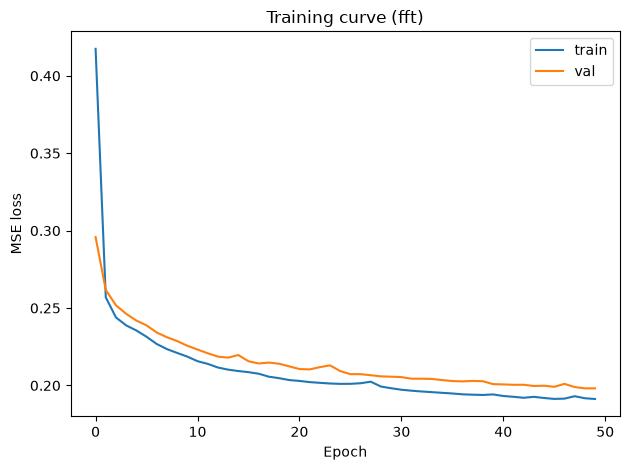

In [14]:
plt.figure()
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title(f'Training curve ({REPRESENTATION})')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'autoencoder_{REPRESENTATION}_loss.png', dpi=100)
plt.show()

## Evaluate — reconstruction error distributions

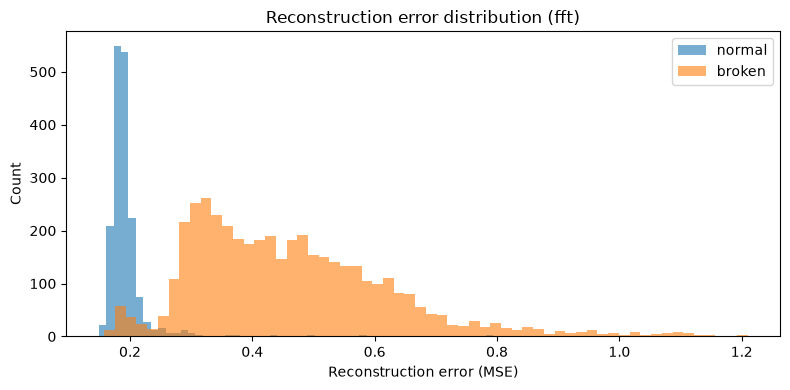

Normal  — mean: 0.1940  std: 0.0443
Broken  — mean: 0.4629  std: 0.1639


In [15]:
X_test_recon = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

# Per-sample MSE reconstruction error
recon_errors = np.mean((X_test - X_test_recon) ** 2, axis=(1, 2, 3))

errors_normal = recon_errors[y_test_bin == 0]
errors_broken = recon_errors[y_test_bin == 1]

plt.figure(figsize=(8, 4))
plt.hist(errors_normal, bins=60, alpha=0.6, label='normal')
plt.hist(errors_broken, bins=60, alpha=0.6, label='broken')
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Count')
plt.title(f'Reconstruction error distribution ({REPRESENTATION})')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'autoencoder_{REPRESENTATION}_error_dist.png', dpi=100)
plt.show()

print(f'Normal  — mean: {errors_normal.mean():.4f}  std: {errors_normal.std():.4f}')
print(f'Broken  — mean: {errors_broken.mean():.4f}  std: {errors_broken.std():.4f}')

## Evaluate — AUROC and threshold selection

AUROC: 0.9790
Threshold (mean+2std of test normals): 0.2826
F1 at threshold: 0.9573


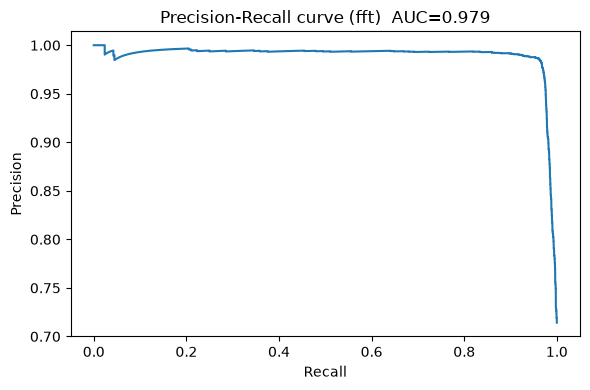

In [16]:
auroc = roc_auc_score(y_test_bin, recon_errors)
print(f'AUROC: {auroc:.4f}')

# Choose threshold: mean + 2*std of normal reconstruction errors on test set.
# In deployment you would use the train normal errors for this — we use test
# here only to inspect the operating point; the saved threshold uses train below.
threshold = errors_normal.mean() + 2 * errors_normal.std()
print(f'Threshold (mean+2std of test normals): {threshold:.4f}')

y_pred = (recon_errors > threshold).astype(int)
f1 = f1_score(y_test_bin, y_pred)
print(f'F1 at threshold: {f1:.4f}')

# Precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test_bin, recon_errors)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall curve ({REPRESENTATION})  AUC={auroc:.3f}')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'autoencoder_{REPRESENTATION}_pr_curve.png', dpi=100)
plt.show()

## Save threshold

Threshold is derived from **train** normal errors (not test) so it can be used
at inference without access to labelled test data.

In [17]:
X_train_normal_recon = model.predict(X_normal, batch_size=BATCH_SIZE, verbose=0)
train_normal_errors  = np.mean((X_normal - X_train_normal_recon) ** 2, axis=(1, 2, 3))

deploy_threshold = train_normal_errors.mean() + 2 * train_normal_errors.std()
np.save(MODEL_DIR / f'autoencoder_{REPRESENTATION}_threshold.npy', deploy_threshold)
print(f'Deployment threshold saved: {deploy_threshold:.4f}')

Deployment threshold saved: 0.2679
